In [1]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

base_dir = 'C:\\Code\\Github\\States_pupil_analysis\\'
os.chdir(base_dir)  # Change the working directory to the current file directory  

# Import your helper functions
from helper_functions.data_loader import DataLoader  # Import the DataLoader class
from helper_functions.data_analyzer import DataAnalyzer
from helper_functions.data_aligner import DataAligner
from helper_functions.data_pipeline import DataPipeline
from helper_functions.data_plotter import Plotter
from helper_functions.data_trial_divider import TrialDivider
from helper_functions.data_trial_plotter import TrialPlotter

In [2]:
# Your datasets list
datasets = [
    # ("HA1-00", "2023-06-27", 'V:'),
    ("HA10-1L", "2023-04-17", 'V:')
    # ("HA1-00", "2023-08-28", 'W:')

]

# datasets = [("HA1-00", "2023-06-27", 'V:'),("HA1-00", "2023-06-29", 'V:')]
# Define the base directory for datasets
base_dir = 'C:\\Code\\Github\\States_pupil_analysis\\datasets\\'

# Now run your pipeline
pipeline = DataPipeline()

# Load the data from the datasets list
data_loaders, celltype_info = pipeline.load_data(datasets,load_celltypes=1) 



Loading data for: Animal: HA10-1L, Date: 2023-04-17, Server: V:


In [3]:
good_trials_all = []
alignment = {}
alignment['type']  = 'pre' 
alignment['data_type']  = 'z_dff'
for data_loader, (key, info) in zip(data_loaders, celltype_info.items()):
    animalID, date = key
    server_info = info  # This will be the celltype information for the corresponding dataset

    celltypes = celltype_info[animalID, date]['neuron_groups']

    # Load the data using the data loader
    # pupil_data = data_loader.load_pupil_data()
    neural_data, good_trials, trial_info, movement_in_imaging, frame_id_events, file_num, velocity_data, imaging = data_loader.load_neural_data(neural_data_type='dff')
    good_trials_all.append(good_trials)
    # latent_states = data_loader.load_latent_states() #could be other things like correct/incorrect or performance metric

    # Align the data
    imaging_frame_lengths = data_loader.load_alignment_data()
    global_frame_ids = data_loader.align_frames_to_session(file_num, frame_id_events, imaging_frame_lengths)

    # Define movement frames by trial
    movement_frames = {}
    
    for trial in range(len(neural_data)):
        if trial in good_trials:
            movement_frames[trial] = {
                'maze_frames': movement_in_imaging[trial]['maze_frames'],
                'reward_frames': movement_in_imaging[trial]['reward_frames'],
                'iti_frames': movement_in_imaging[trial]['iti_frames']
            }
        else:
            movement_frames[trial] = None

    # Initialize the DataAligner with the new parameters
    aligner = DataAligner(neural_data, movement_frames, velocity_data, global_frame_ids, good_trials)

    # Align the data to the desired epoch (e.g., 'maze', 'reward', 'iti', or 'all')
    align_info, alignment_frames, left_padding, right_padding = aligner.find_align_info(imaging, 30, alternative_alignment=False) #neural (mean across cells), pupil, velocity, and neural_all (single cells)
    aligned_imaging, imaging_array, align_info, frames = aligner.align_behavior_data( imaging, align_info, alignment_frames, left_padding, right_padding, 
                       alignment = alignment, cell_ids=None)
    

[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 187, 188, 189, 190, 191, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 247, 248, 249, 250, 251, 252, 253, 254

In [4]:
# In your notebook
fields_to_separate = ['correct', 'condition']
trial_divider = TrialDivider()
all_conditions, condition_array = trial_divider.divide_trials_from_df(trial_info_df=trial_info,
    good_trials=good_trials,
    fields_to_separate=fields_to_separate)

# Example: Print conditions and their trial counts
for trials, comb, label in all_conditions:
    print(f"{label}: {len(trials)} trials")


Incorrect/Right: 36 trials
Incorrect/Left: 14 trials
Correct/Right: 82 trials
Correct/Left: 98 trials


(<Figure size 600x1200 with 8 Axes>,
 array([<Axes: title={'center': 'Incorrect/Right\n(n=36 trials, 385 cells)'}, ylabel='Cells'>,
        <Axes: title={'center': 'Incorrect/Left\n(n=14 trials, 385 cells)'}, ylabel='Cells'>,
        <Axes: title={'center': 'Correct/Right\n(n=82 trials, 385 cells)'}, ylabel='Cells'>,
        <Axes: title={'center': 'Correct/Left\n(n=98 trials, 385 cells)'}, xlabel='Time (s)', ylabel='Cells'>],
       dtype=object))

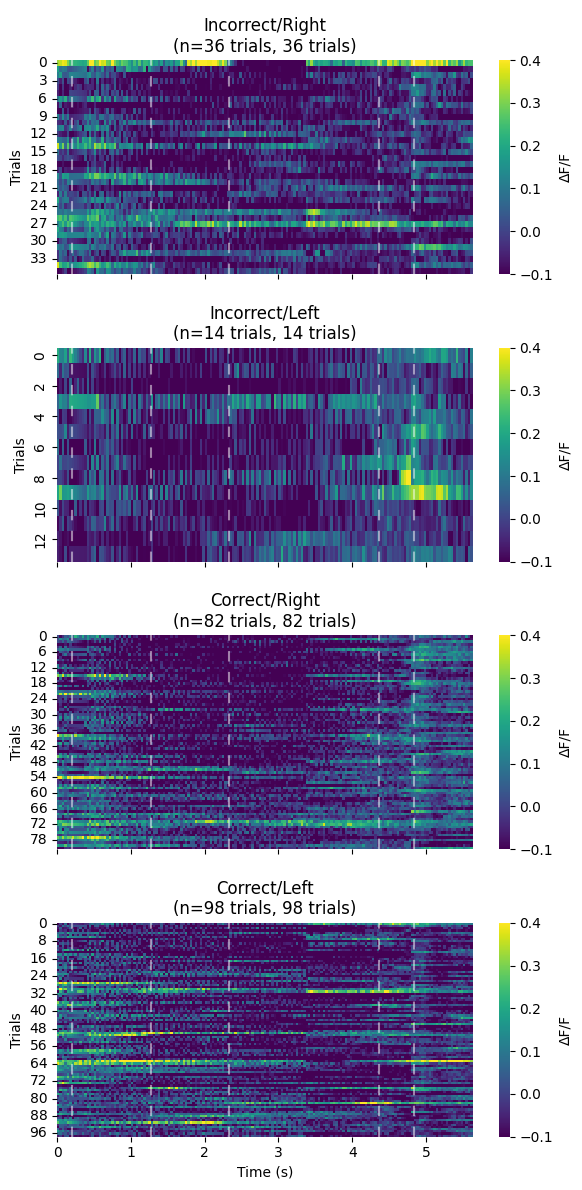

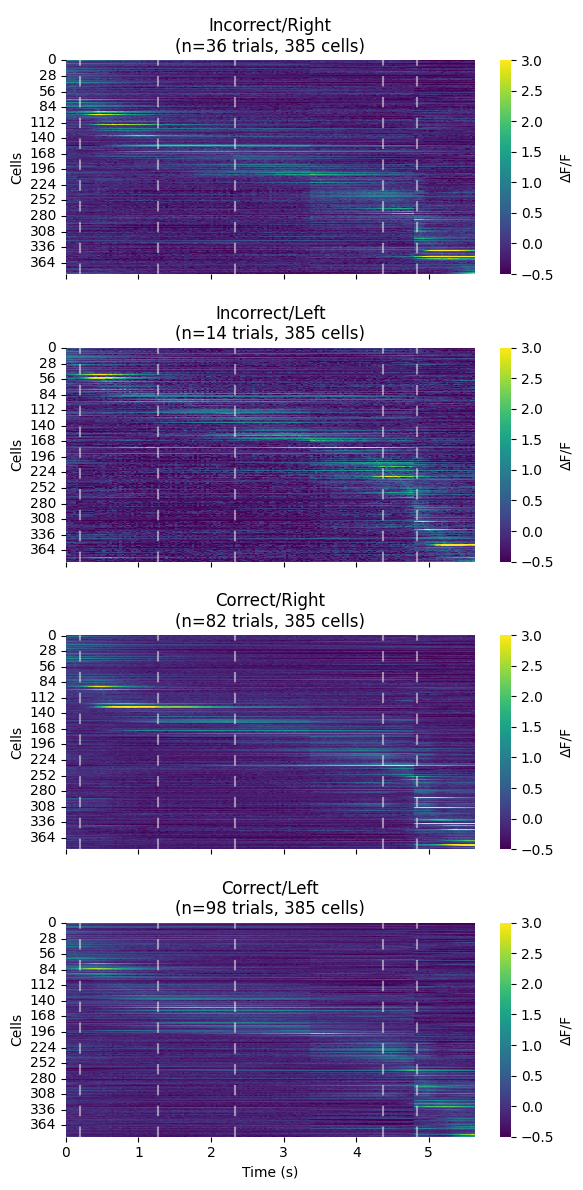

In [5]:
# Create plotter instance
trial_plotter = TrialPlotter()

# Plot heatmaps for all cells
trial_plotter.plot_condition_heatmaps(
    aligned_imaging=aligned_imaging,
    all_conditions=all_conditions,
    save_path='condition_heatmaps_all_cells.pdf',
    vmin = -.1,
    vmax = .4
)

# Plot heatmaps for specific cell types (e.g., PV cells)
current_cells = celltypes['pyr']
trial_plotter.plot_condition_heatmaps(
    aligned_imaging=aligned_imaging,
    all_conditions=all_conditions,
    cell_ids=current_cells,
    average_type='trials',
    save_path='condition_heatmaps_pyr_cells.pdf',
    vmin = -.5,
    vmax = 3
)

example

In [6]:
[
trial['turn_frame'][0] - 1 if isinstance(trial['turn_frame'], list) else trial['turn_frame'] - 1
for trial in imaging_array
]

[array([[170]], dtype=uint8),
 array([[451]], dtype=uint16),
 array([[172]], dtype=uint8),
 array([[220]], dtype=uint8),
 array([[172]], dtype=uint8),
 array([[155]], dtype=uint8),
 array([[167]], dtype=uint8),
 array([[145]], dtype=uint8),
 array([[164]], dtype=uint8),
 array([[189]], dtype=uint8),
 array([[184]], dtype=uint8),
 array([[164]], dtype=uint8),
 array([[163]], dtype=uint8),
 array([[162]], dtype=uint8),
 array([[158]], dtype=uint8),
 array([[165]], dtype=uint8),
 array([[278]], dtype=uint16),
 array([[179]], dtype=uint8),
 array([[163]], dtype=uint8),
 array([[153]], dtype=uint8),
 array([[158]], dtype=uint8),
 array([[268]], dtype=uint16),
 array([[320]], dtype=uint16),
 array([[179]], dtype=uint8),
 array([[156]], dtype=uint8),
 array([[168]], dtype=uint8),
 array([[176]], dtype=uint8),
 array([[169]], dtype=uint8),
 array([[151]], dtype=uint8),
 array([[190]], dtype=uint8),
 array([[172]], dtype=uint8),
 array([[160]], dtype=uint8),
 array([[168]], dtype=uint8),
 array

In [7]:
[trial['turn_frame'][0] for trial in imaging_array]

[array([171], dtype=uint8),
 array([452], dtype=uint16),
 array([173], dtype=uint8),
 array([221], dtype=uint8),
 array([173], dtype=uint8),
 array([156], dtype=uint8),
 array([168], dtype=uint8),
 array([146], dtype=uint8),
 array([165], dtype=uint8),
 array([190], dtype=uint8),
 array([185], dtype=uint8),
 array([165], dtype=uint8),
 array([164], dtype=uint8),
 array([163], dtype=uint8),
 array([159], dtype=uint8),
 array([166], dtype=uint8),
 array([279], dtype=uint16),
 array([180], dtype=uint8),
 array([164], dtype=uint8),
 array([154], dtype=uint8),
 array([159], dtype=uint8),
 array([269], dtype=uint16),
 array([321], dtype=uint16),
 array([180], dtype=uint8),
 array([157], dtype=uint8),
 array([169], dtype=uint8),
 array([177], dtype=uint8),
 array([170], dtype=uint8),
 array([152], dtype=uint8),
 array([191], dtype=uint8),
 array([173], dtype=uint8),
 array([161], dtype=uint8),
 array([169], dtype=uint8),
 array([179], dtype=uint8),
 array([182], dtype=uint8),
 array([168], dt